# 📝 Exercise M4.02

In the previous notebook, we showed that we can add new features based on the
original feature `x` to make the model more expressive, for instance `x ** 2` or
`x ** 3`. In that case we only used a single feature in `data`.

The aim of this notebook is to train a linear regression algorithm on a
dataset with more than a single feature. In such a "multi-dimensional" feature
space we can derive new features of the form `x1 * x2`, `x2 * x3`, etc.
Products of features are usually called "non-linear" or "multiplicative"
interactions between features.

Feature engineering can be an important step of a model pipeline as long as
the new features are expected to be predictive. For instance, think of a
classification model to decide if a patient has risk of developing a heart
disease. This would depend on the patient's Body Mass Index which is defined
as `weight / height ** 2`.

We load the penguins dataset. We first use a set of 3 numerical
features to predict the target, i.e. the body mass of the penguin.

<div class="admonition note alert alert-info">
<p class="first admonition-title" style="font-weight: bold;">Note</p>
<p class="last">If you want a deeper overview regarding this dataset, you can refer to the
Appendix - Datasets description section at the end of this MOOC.</p>
</div>

In [1]:
import pandas as pd

penguins = pd.read_csv("../datasets/penguins.csv")

columns = ["Flipper Length (mm)", "Culmen Length (mm)", "Culmen Depth (mm)"]
target_name = "Body Mass (g)"

# Remove lines with missing values for the columns of interest
penguins_non_missing = penguins[columns + [target_name]].dropna()

data = penguins_non_missing[columns]
target = penguins_non_missing[target_name]
data

,Flipper Length (mm),Culmen Length (mm),Culmen Depth (mm)
0,181.0,39.1,18.7
1,186.0,39.5,17.4
2,195.0,40.3,18.0
4,193.0,36.7,19.3
5,190.0,39.3,20.6
...,...,...,...
339,207.0,55.8,19.8
340,202.0,43.5,18.1
341,193.0,49.6,18.2
342,210.0,50.8,19.0


Now it is your turn to train a linear regression model on this dataset. First,
create a linear regression model.

In [2]:
from sklearn.linear_model import LinearRegression

linear_regression = LinearRegression()

Execute a cross-validation with 10 folds and use the mean absolute error (MAE)
as metric.

In [3]:
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import mean_absolute_error

target_linear_regression = cross_val_predict(
    linear_regression,
    data,
    target,
    cv=10
)

mae = mean_absolute_error(target, target_linear_regression)
print(f"Mean Absolute Error: {mae}")

Mean Absolute Error: 337.28817233712675


Compute the mean and std of the MAE in grams (g). Remember you have to revert
the sign introduced when metrics start with `neg_`, such as in
`"neg_mean_absolute_error"`.

In [4]:
from sklearn.model_selection import cross_val_score

cv_linear_regression = cross_val_score(
    linear_regression,
    data,
    target,
    cv=10,
    scoring="neg_mean_absolute_error"
)

print(f"Mean Absolute Error: {-cv_linear_regression.mean():.3f} ± {cv_linear_regression.std():.3f}")

Mean Absolute Error: 337.071 ± 84.868


Now create a pipeline using `make_pipeline` consisting of a
`PolynomialFeatures` and a linear regression. Set `degree=2` and
`interaction_only=True` to the feature engineering step. Remember not to
include a "bias" feature (that is a constant-valued feature) to avoid
introducing a redundancy with the intercept of the subsequent linear
regression model.

You may want to use the `.set_output(transform="pandas")` method of the
pipeline to answer the next question.

In [11]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import PolynomialFeatures

model = make_pipeline(
    PolynomialFeatures(degree=2, interaction_only=True, include_bias=False),
    linear_regression
).set_output(transform="pandas")

Transform the first 5 rows of the dataset and look at the column names. How
many features are generated at the output of the `PolynomialFeatures` step in
the previous pipeline?

In [14]:
model.fit(data, target)
model[0].transform(data[:5])

,Flipper Length (mm),Culmen Length (mm),Culmen Depth (mm),Flipper Length (mm) Culmen Length (mm),Flipper Length (mm) Culmen Depth (mm),Culmen Length (mm) Culmen Depth (mm)
0,181.0,39.1,18.7,7077.1,3384.7,731.17
1,186.0,39.5,17.4,7347.0,3236.4,687.30
2,195.0,40.3,18.0,7858.5,3510.0,725.40
4,193.0,36.7,19.3,7083.1,3724.9,708.31
5,190.0,39.3,20.6,7467.0,3914.0,809.58


*3 new features were created*

Check that the values for the new interaction features are correct for a few
of them.

In [17]:
181*39.1

7077.1

Use the same cross-validation strategy as done previously to estimate the mean
and std of the MAE in grams (g) for such a pipeline. Compare with the results
without feature engineering.

In [18]:
cv_model = cross_val_score(
    model,
    data,
    target,
    cv=10,
    scoring="neg_mean_absolute_error"
)

print(f"Mean Absolute Error: {-cv_model.mean():.3f} ± {cv_model.std():.3f}")

Mean Absolute Error: 301.790 ± 44.340


### Feature Engineering vs. Raw

In [21]:
print(f"F.E.: {-cv_model.mean():.3f} ± {cv_model.std():.3f} vs. Raw: {-cv_linear_regression.mean():.3f} ± {cv_linear_regression.std():.3f}")
print("Feature Engineering is superior.")

F.E.: 301.790 ± 44.340 vs. Raw: 337.071 ± 84.868
Feature Engineering is superior.



Now let's try to build an alternative pipeline with an adjustable number of
intermediate features while keeping a similar predictive power. To do so, try
using the `Nystroem` transformer instead of `PolynomialFeatures`. Set the
kernel parameter to `"poly"` and `degree` to 2. Adjust the number of
components to be as small as possible while keeping a good cross-validation
performance.

Hint: Use a `ValidationCurveDisplay` with `param_range = np.array([5, 10, 50,
100])` to find the optimal `n_components`.

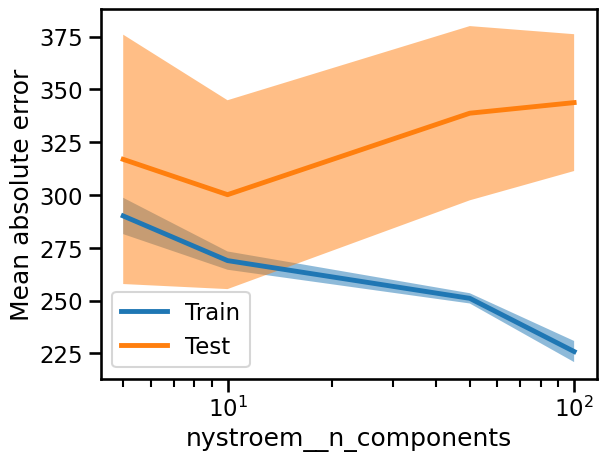

In [31]:
from sklearn.kernel_approximation import Nystroem
from sklearn.model_selection import ValidationCurveDisplay

nystroem_model = make_pipeline(
    Nystroem(kernel="poly", degree=2),
    linear_regression
)

param_range = np.array([5, 10, 50, 100])

_ = ValidationCurveDisplay.from_estimator(
    nystroem_model,
    data,
    target,
    param_name="nystroem__n_components",
    param_range=param_range,
    cv=10,
    scoring="neg_mean_absolute_error",
    negate_score=True
)

How do the mean and std of the MAE for the Nystroem pipeline with optimal
`n_components` compare to the other previous models?

In [32]:
cv_model = cross_val_score(
    nystroem_model,
    data,
    target,
    cv=10,
    scoring="neg_mean_absolute_error"
)

print(f"Mean Absolute Error: {-cv_model.mean():.3f} ± {cv_model.std():.3f}")

Mean Absolute Error: 365.308 ± 58.924


Nyström > Previous Models